### 單變量


N = 10, Sample Mean = -0.2583
N = 30, Sample Mean = 0.2535
N = 50, Sample Mean = 0.1066
N = 100, Sample Mean = -0.2543
N = 500, Sample Mean = -0.0305
N = 1000, Sample Mean = 0.0292


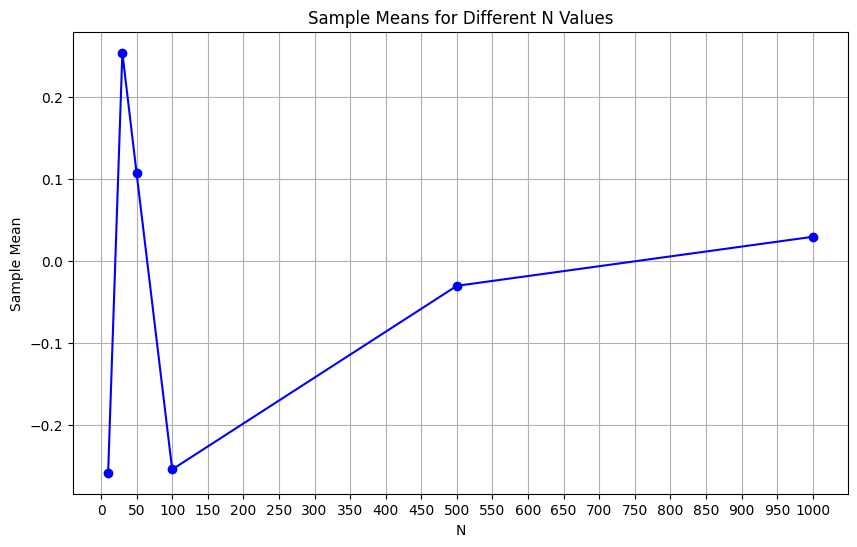

In [9]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# 定義不同的 N 值
N_values = [10, 30, 50, 100, 500, 1000]
mu_true = 0
sigma_true = 1

# 儲存每個 N 值對應的樣本平均值
sample_means = []

# 生成樣本並計算平均值
for N in N_values:
    samples = stats.norm.rvs(loc=mu_true, scale=sigma_true, size=N)
    sample_mean = np.mean(samples)
    sample_means.append(sample_mean)
    print(f'N = {N}, Sample Mean = {sample_mean:.4f}')

# 繪製折線圖
plt.figure(figsize=(10, 6))
plt.plot(N_values, sample_means, marker='o', linestyle='-', color='b')
plt.title('Sample Means for Different N Values')
plt.xlabel('N')
plt.ylabel('Sample Mean')
plt.grid(True)
plt.show()

MLE of mu: -0.0809, MLE of sigma: 1.0094


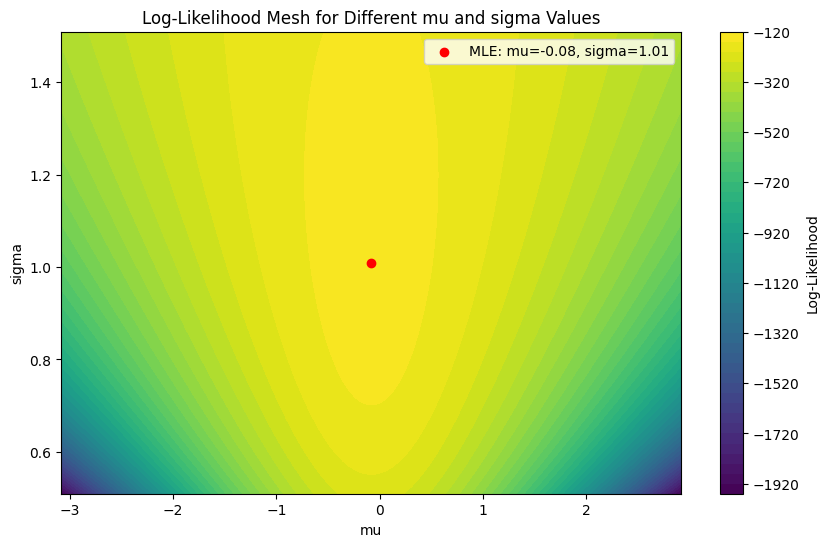

In [11]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# 生成 N 個來自均值為 0 和標準差為 1 的常態分佈的樣本
N = 100
mu_true = 0
sigma_true = 1
samples = stats.norm.rvs(loc=mu_true, scale=sigma_true, size=N)

# 定義負對數似然函數
def neg_log_likelihood(params):
    mu, sigma = params
    if sigma <= 0:  # 確保標準差為正
        return np.inf
    return -np.sum(np.log(stats.norm.pdf(samples, loc=mu, scale=sigma)))

# 使用 minimize 函數來最小化負對數似然函數
initial_guess = [0, 1]
result = minimize(neg_log_likelihood, initial_guess)
mle_mu, mle_sigma = result.x
print(f'MLE of mu: {mle_mu:.4f}, MLE of sigma: {mle_sigma:.4f}')

# 繪製網格圖
mu_range = np.linspace(mle_mu - 3, mle_mu + 3, 100)
sigma_range = np.linspace(mle_sigma - 0.5, mle_sigma + 0.5, 100)
mu_grid, sigma_grid = np.meshgrid(mu_range, sigma_range)
log_likelihood_grid = np.zeros_like(mu_grid)

for i in range(mu_grid.shape[0]):
    for j in range(mu_grid.shape[1]):
        log_likelihood_grid[i, j] = -neg_log_likelihood([mu_grid[i, j], sigma_grid[i, j]])

plt.figure(figsize=(10, 6))
plt.contourf(mu_grid, sigma_grid, log_likelihood_grid, levels=50, cmap='viridis')
plt.colorbar(label='Log-Likelihood')
plt.scatter(mle_mu, mle_sigma, color='red', label=f'MLE: mu={mle_mu:.2f}, sigma={mle_sigma:.2f}')
plt.title('Log-Likelihood Mesh for Different mu and sigma Values')
plt.xlabel('mu')
plt.ylabel('sigma')
plt.legend()
plt.show()

MLE of mu: 0.2930, MLE of sigma: 0.9847


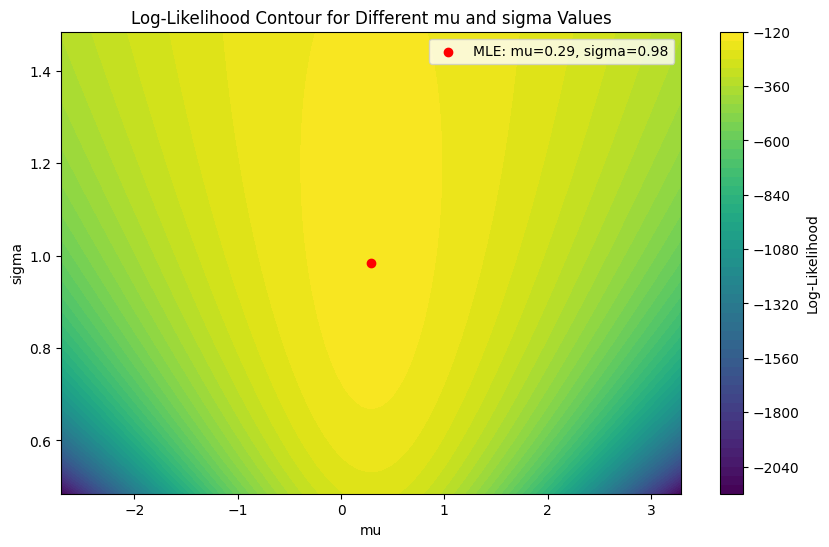

In [13]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# 生成 N 個來自均值為 0 和標準差為 1 的常態分佈的樣本
N = 100
mu_true = 0
sigma_true = 1
samples = stats.norm.rvs(loc=mu_true, scale=sigma_true, size=N)

# 定義負對數似然函數
def neg_log_likelihood(params):
    mu, sigma = params
    if sigma <= 0:  # 確保標準差為正
        return np.inf
    return -np.sum(np.log(stats.norm.pdf(samples, loc=mu, scale=sigma)))

# 使用 minimize 函數來最小化負對數似然函數
initial_guess = [0, 1]
result = minimize(neg_log_likelihood, initial_guess)
mle_mu, mle_sigma = result.x
print(f'MLE of mu: {mle_mu:.4f}, MLE of sigma: {mle_sigma:.4f}')

# 繪製網格圖
mu_range = np.linspace(mle_mu - 3, mle_mu + 3, 100)
sigma_range = np.linspace(mle_sigma - 0.5, mle_sigma + 0.5, 100)
mu_grid, sigma_grid = np.meshgrid(mu_range, sigma_range)
log_likelihood_grid = np.zeros_like(mu_grid)

for i in range(mu_grid.shape[0]):
    for j in range(mu_grid.shape[1]):
        log_likelihood_grid[i, j] = -neg_log_likelihood([mu_grid[i, j], sigma_grid[i, j]])

plt.figure(figsize=(10, 6))
plt.contourf(mu_grid, sigma_grid, log_likelihood_grid, levels=50, cmap='viridis')
plt.colorbar(label='Log-Likelihood')
plt.scatter(mle_mu, mle_sigma, color='red', label=f'MLE: mu={mle_mu:.2f}, sigma={mle_sigma:.2f}')
plt.title('Log-Likelihood Contour for Different mu and sigma Values')
plt.xlabel('mu')
plt.ylabel('sigma')
plt.legend()
plt.show()